#**BRAIN MODELING PROJECT - Lab2 Neuron Models**

Group members:


*   Gala Miladinović, 515653
*   Mina Miladinović, 515650
*   Gabriel Leguizamón, 513217

February 2026.

# Izhikevich model:
It is a 2D model with two state variables:
- v(t): membrane potential;
- u(t): 'recovery' variable.

The pair of coupled first order equations of the model are:

$\frac{dv}{dt}=0.04v^2+5v+140-u+I\\
\frac{du}{dt}=a(bv-u)$

For the **after-spike resetting**: if v>30 mV then v->c, u->u+d;

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Izhikevich neuron model + analysis utilities

def izhikevich_sim(a, b, c, d, dt, time, I, V_rest=-70.0, u0=None, v_peak=30.0):
    """Simulate the Izhikevich neuron (Euler + spike reset)."""
    n = len(time)
    V = np.zeros(n, dtype=float)
    u = np.zeros(n, dtype=float)

    V[0] = float(V_rest)
    u[0] = float(b * V_rest) if (u0 is None) else float(u0)

    spike_times = []

    for k in range(1, n):
        if V[k-1] < v_peak:
            dv = 0.04 * V[k-1]**2 + 5.0 * V[k-1] + 140.0 - u[k-1] + I[k-1]
            du = a * (b * V[k-1] - u[k-1])
            V[k] = V[k-1] + dt * dv
            u[k] = u[k-1] + dt * du
        else:
            # mark spike peak at previous sample (for plotting)
            V[k-1] = v_peak
            # reset
            V[k] = c
            u[k] = u[k-1] + d
            spike_times.append(float(time[k-1]))

    return V, u, spike_times


In [ ]:
def plot_v_and_I(title, time, V, I):
    """Plot input current I(t) and membrane potential V(t)."""
    fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    ax[0].plot(time, I)
    ax[0].set_ylabel('I (a.u.)')
    ax[0].set_title(title)

    ax[1].plot(time, V)
    ax[1].set_ylabel('V (mV)')
    ax[1].set_xlabel('Time (ms)')

    plt.tight_layout()
    plt.show()


def plot_phase_plane(title, V, u):
    """Phase-plane trajectory in (V, u)."""
    plt.figure(figsize=(6, 5))
    plt.plot(V, u)
    plt.xlabel('V (mV)')
    plt.ylabel('u')
    plt.title(title + ' (phase plane: V–u)')
    plt.tight_layout()
    plt.show()

In [ ]:
def firing_rate(spike_times, t_start=None, t_end=None):
    """Compute firing rate (Hz) within [t_start, t_end]."""
    if len(spike_times) == 0:
        return 0.0
    if t_start is None:
        t_start = spike_times[0]
    if t_end is None:
        t_end = spike_times[-1]

    st = [s for s in spike_times if (s >= t_start and s <= t_end)]
    if len(st) < 2:
        return 0.0

    duration_s = (t_end - t_start) / 1000.0
    return (len(st) / duration_s) if duration_s > 0 else 0.0


In [ ]:
# Backward-compatible wrappers (safe to keep while refactoring)
def izhikevic_model(a, b, c, d, dt, time, I, V_rest=-70.0):
    """Compatibility wrapper: old API returned only V."""
    V, u, spikes = izhikevich_sim(a, b, c, d, dt, time, I, V_rest=V_rest, u0=-15.0)
    return V

def plotting(title, time, V, I):
    """Compatibility wrapper for older plotting() calls."""
    plot_v_and_I(title, time, V, I)


In [ ]:
#setting time and input current

t=1000 # simulation len
dt=0.5 # time step for the integration
time=np.arange(0,t+dt,dt)
I=10 # current step amplitude
I_=np.zeros(len(time))
I_[200:1500]=I

**Regular spiking**: neuronal activity where action potentials are generated in a regular and repetitive manner (constant firing frequency).

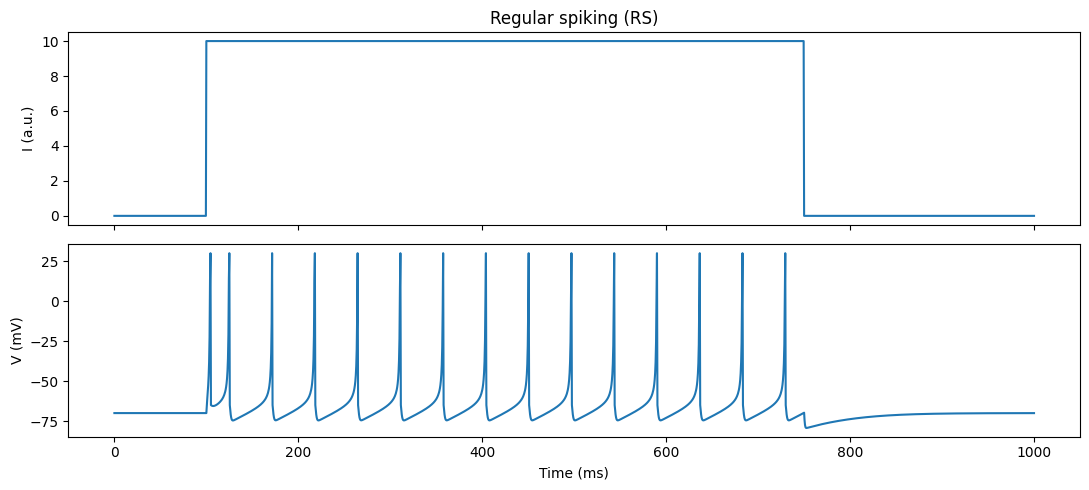

Regular spiking (RS): spikes=15, rate (100–750 ms) ≈ 23.1 Hz


In [ ]:
#parameter initialization for RS
a=0.02
b=0.2
c=-65
d=8

V, u, spikes = izhikevich_sim(a, b, c, d, dt, time, I_)

plot_v_and_I('Regular spiking (RS)', time, V, I_)
print(f"Regular spiking (RS): spikes={len(spikes)}, rate (100–750 ms) ≈ {firing_rate(spikes, 100, 750):.1f} Hz")

**Intrinsically bursting**:  neuron fires a stereotypical burst of spikes followed by repetitive single spike.

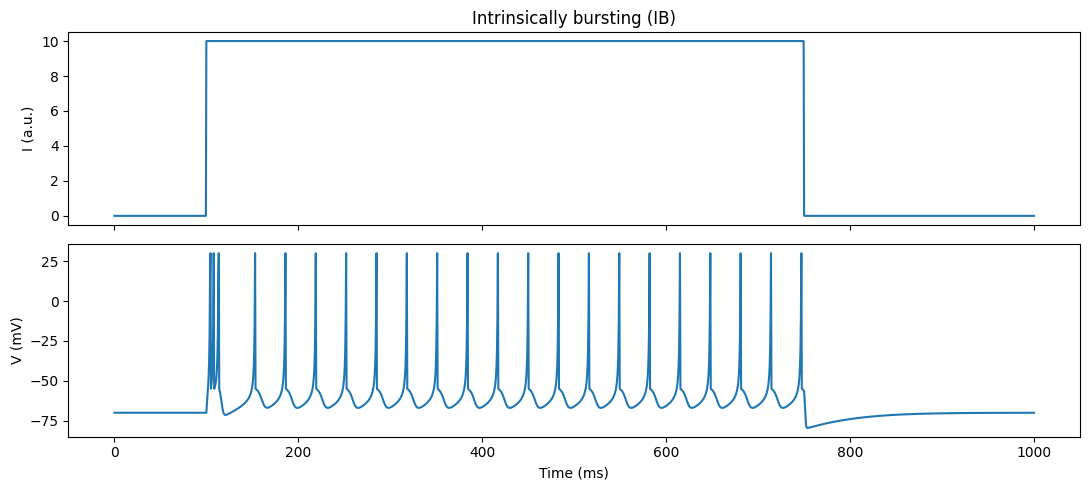

Intrinsically bursting (IB): spikes=22, rate (100–750 ms) ≈ 33.8 Hz


In [ ]:
#parameter initialization for IB
a=0.02
b=0.2
c=-55
d=4

V, u, spikes = izhikevich_sim(a, b, c, d, dt, time, I_)

plot_v_and_I('Intrinsically bursting (IB)', time, V, I_)
print(f"Intrinsically bursting (IB): spikes={len(spikes)}, rate (100–750 ms) ≈ {firing_rate(spikes, 100, 750):.1f} Hz")

**Chatting**: neuron exhibits bursts of closely spaced spike, with a given inter-burst frequency.

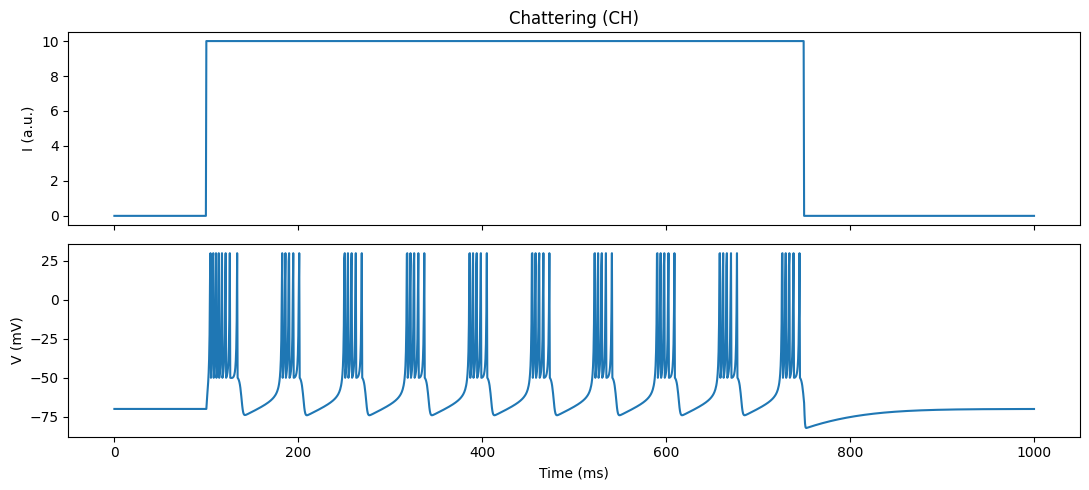

Chattering (CH): spikes=53, rate (100–750 ms) ≈ 81.5 Hz


In [ ]:
#parameter initialization for CH
a=0.02
b=0.2
c=-50
d=2

V, u, spikes = izhikevich_sim(a, b, c, d, dt, time, I_)

plot_v_and_I('Chattering (CH)', time, V, I_)
print(f"Chattering (CH): spikes={len(spikes)}, rate (100–750 ms) ≈ {firing_rate(spikes, 100, 750):.1f} Hz")

**Fast spiking**: neuron fires periodic trains of action potentials with extremely high frequency.

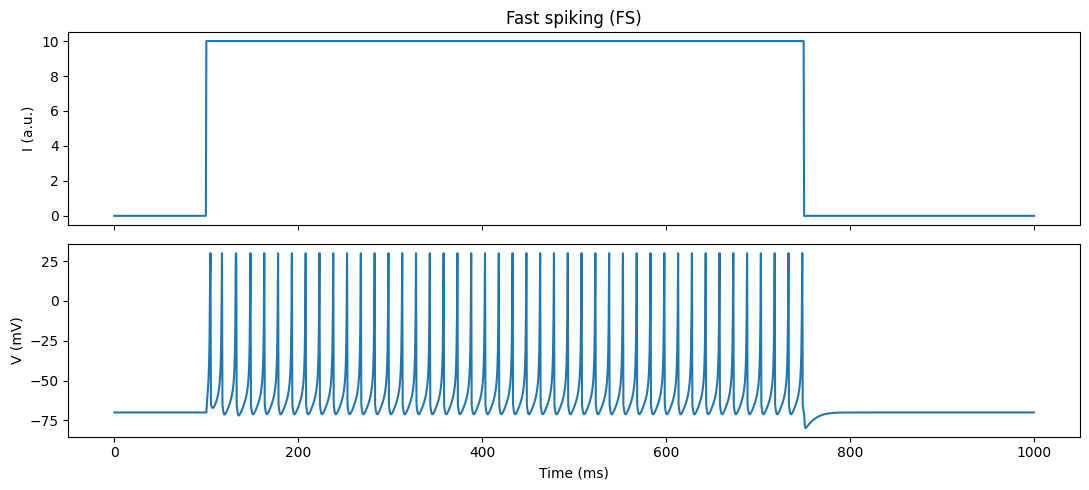

Fast spiking (FS): spikes=44, rate (100–750 ms) ≈ 67.7 Hz


In [ ]:
#parameter initialization for FS
a=0.1
b=0.2
c=-65
d=8

V, u, spikes = izhikevich_sim(a, b, c, d, dt, time, I_)

plot_v_and_I('Fast spiking (FS)', time, V, I_)
print(f"Fast spiking (FS): spikes={len(spikes)}, rate (100–750 ms) ≈ {firing_rate(spikes, 100, 750):.1f} Hz")

**Low-threshold spiking**: neuron fires high-frequency trains of action potentials, but with a prominent spike
frequency adaptation.

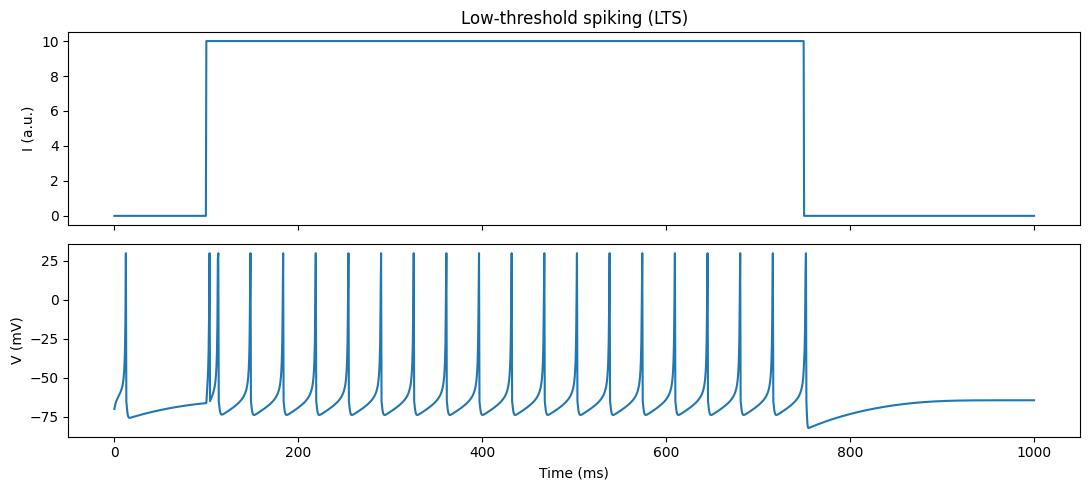

Low-threshold spiking (LTS): spikes=21, rate (100–750 ms) ≈ 29.2 Hz


In [ ]:
#parameter initialization for LTS
a=0.02
b=0.25
c=-65
d=8

V, u, spikes = izhikevich_sim(a, b, c, d, dt, time, I_)

plot_v_and_I('Low-threshold spiking (LTS)', time, V, I_)
print(f"Low-threshold spiking (LTS): spikes={len(spikes)}, rate (100–750 ms) ≈ {firing_rate(spikes, 100, 750):.1f} Hz")

**Resonator**:  for neurons which have damped or sustained subthreshold oscillations.

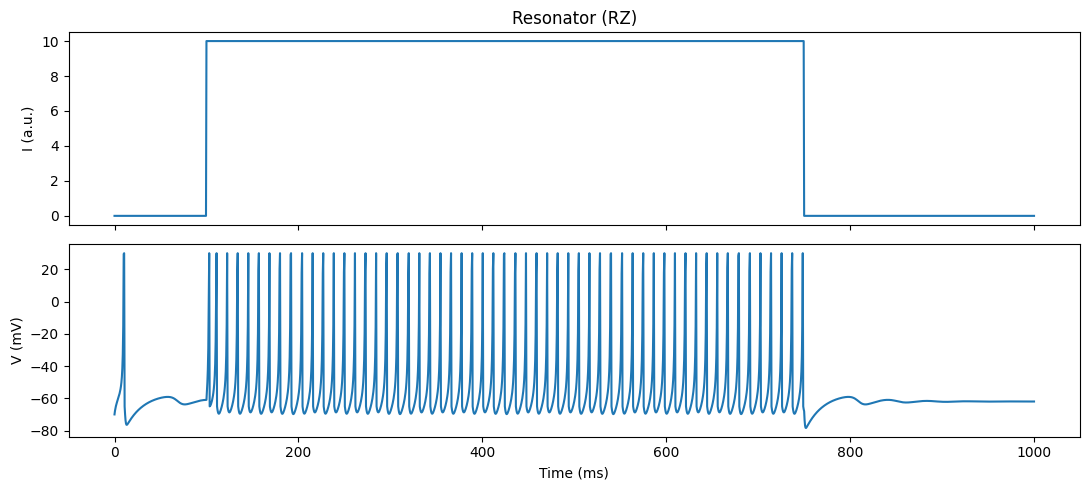

Resonator (RZ): spikes=58, rate (100–750 ms) ≈ 87.7 Hz


In [ ]:
#parameter initialization for RZ
a=0.1
b=0.262
c=-65
d=8

V, u, spikes = izhikevich_sim(a, b, c, d, dt, time, I_)

plot_v_and_I('Resonator (RZ)', time, V, I_)
print(f"Resonator (RZ): spikes={len(spikes)}, rate (100–750 ms) ≈ {firing_rate(spikes, 100, 750):.1f} Hz")

# Extensions: analysis + reusable experiments

1. **Return the recovery variable `u` + spike times** (so we can analyze adaptation/bursting, not just voltage).
2. **Reusable stimulus generators** (step, pulses, ramp, sine) so we don’t hard-code `I_` every time.
3. **Spike detection + firing-rate tools** (compute spike times, ISI, firing rate).
4. **f–I curve** (firing rate vs input current amplitude) for any neuron type.
5. **Phase-plane plot (v–u)** (helps explain why different parameter sets behave differently).
6. **Multi-type comparison figure** (same stimulus, multiple neuron types in one compact plot).


## Utility functions
The Izhikevich simulator (`izhikevich_sim`) and analysis helpers are defined above.

In [ ]:
# Parameter presets
PRESETS = {
    'Regular spiking (RS)': dict(a=0.02, b=0.2,   c=-65, d=8),
    'Intrinsically bursting (IB)': dict(a=0.02, b=0.2,   c=-55, d=4),
    'Chattering (CH)': dict(a=0.02, b=0.2,   c=-50, d=2),
    'Fast spiking (FS)': dict(a=0.1,  b=0.2,   c=-65, d=8),
    'Low-threshold spiking (LTS)': dict(a=0.02, b=0.25,  c=-65, d=8),
    'Resonator (RZ)': dict(a=0.1,  b=0.262, c=-65, d=8),
}


In [ ]:
# Stimulus generators (can reuse experiments cleanly)

def make_time(t_max=1000.0, dt=0.5):
    return np.arange(0.0, t_max + dt, dt)

def stim_step(time, amp=10.0, t_on=100.0, t_off=750.0, baseline=0.0):
    I = baseline * np.ones_like(time, dtype=float)
    I[(time >= t_on) & (time <= t_off)] = amp
    return I

def stim_pulse_train(time, amp=10.0, t_start=100.0, n_pulses=5, width=10.0, period=50.0, baseline=0.0):
    I = baseline * np.ones_like(time, dtype=float)
    for k in range(n_pulses):
        t_on = t_start + k * period
        t_off = t_on + width
        I[(time >= t_on) & (time <= t_off)] = amp
    return I

def stim_ramp(time, amp_end=10.0, t_on=100.0, t_off=750.0, baseline=0.0):
    I = baseline * np.ones_like(time, dtype=float)
    mask = (time >= t_on) & (time <= t_off)
    if np.any(mask):
        I[mask] = np.linspace(baseline, amp_end, mask.sum())
    return I

def stim_sine(time, amp=5.0, freq_hz=5.0, baseline=0.0):
    # time in ms -> seconds
    t_s = time / 1000.0
    I = baseline + amp * np.sin(2 * np.pi * freq_hz * t_s)
    return I


## Demo 1: replicate the original experiments (but now with `u` + spike times)



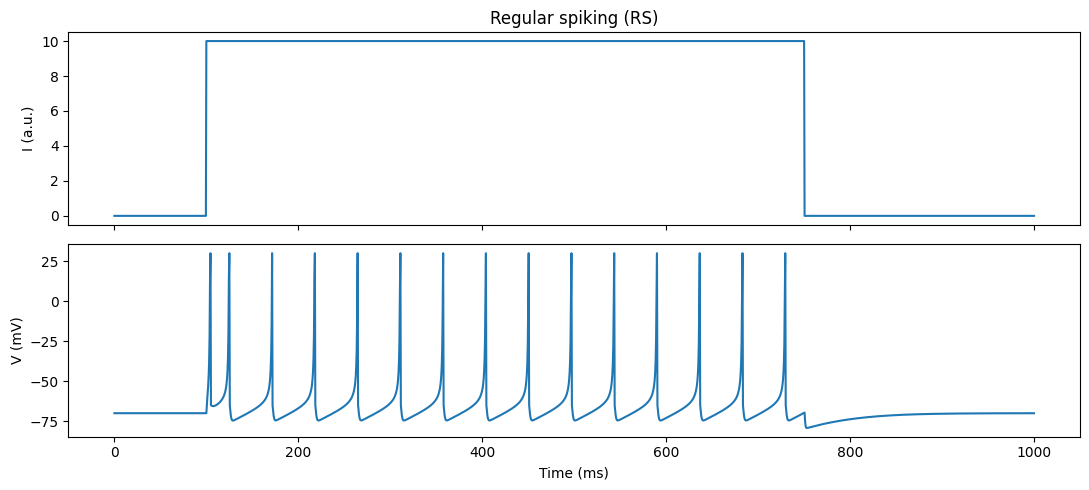

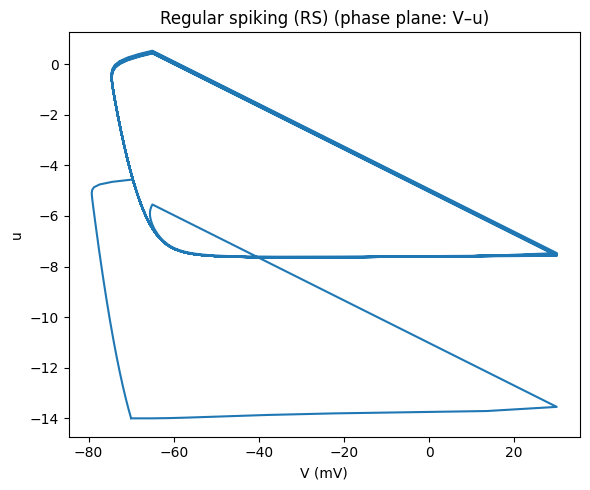

Regular spiking (RS): spikes=15, firing rate (100–750 ms) ≈ 23.1 Hz


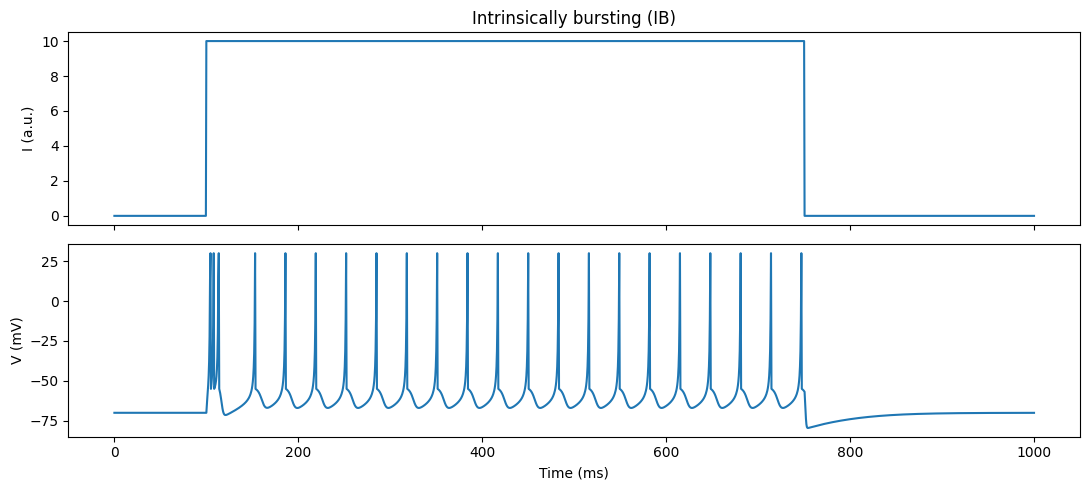

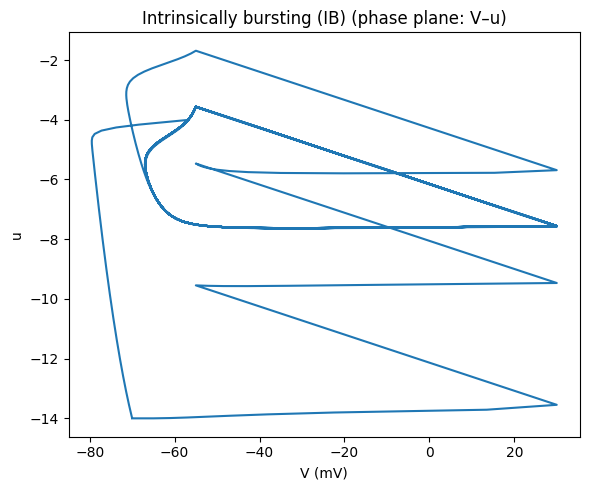

Intrinsically bursting (IB): spikes=22, firing rate (100–750 ms) ≈ 33.8 Hz


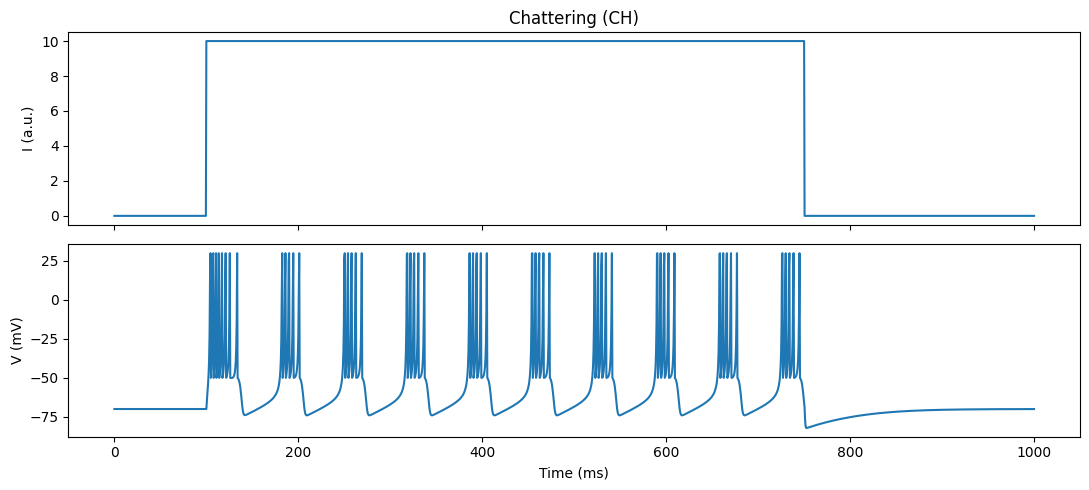

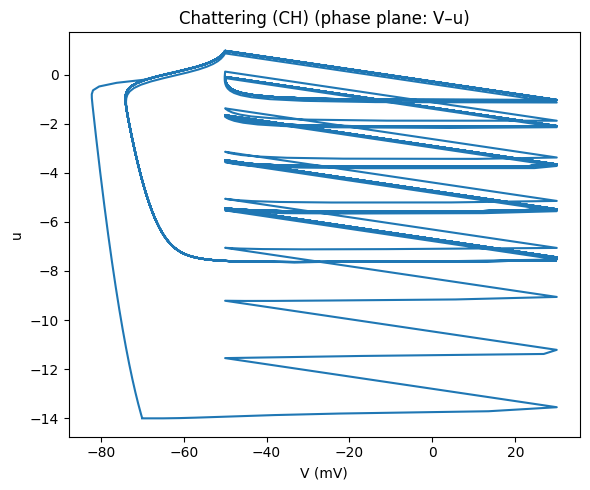

Chattering (CH): spikes=53, firing rate (100–750 ms) ≈ 81.5 Hz


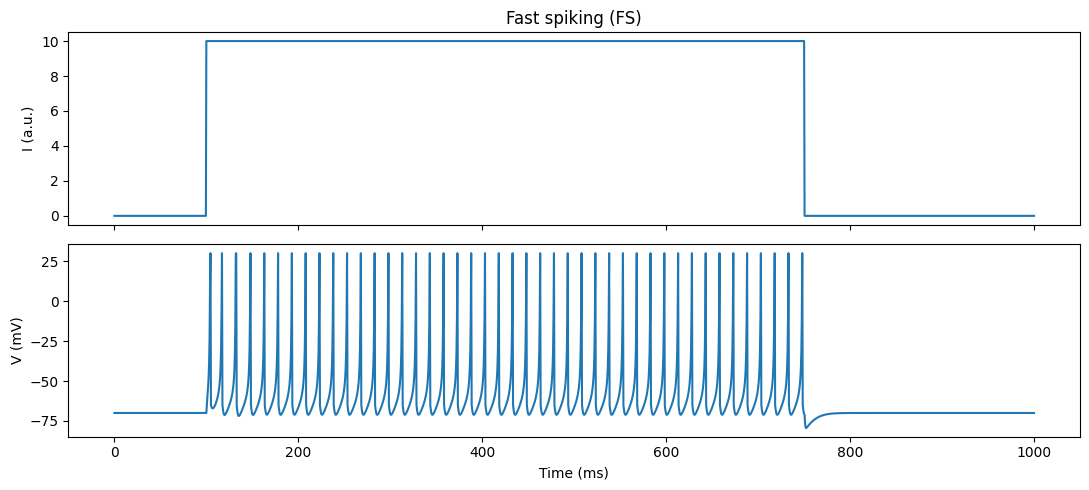

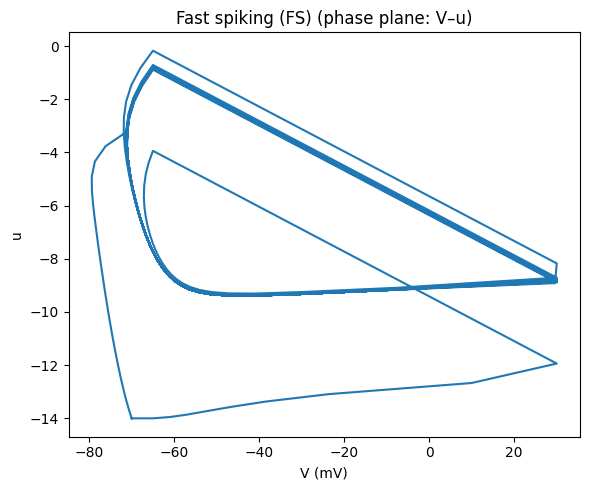

Fast spiking (FS): spikes=44, firing rate (100–750 ms) ≈ 67.7 Hz


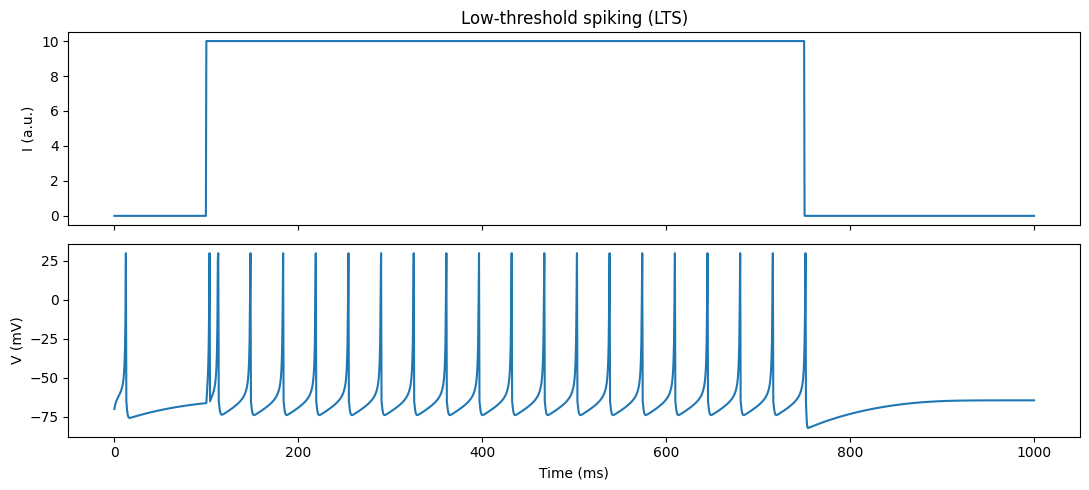

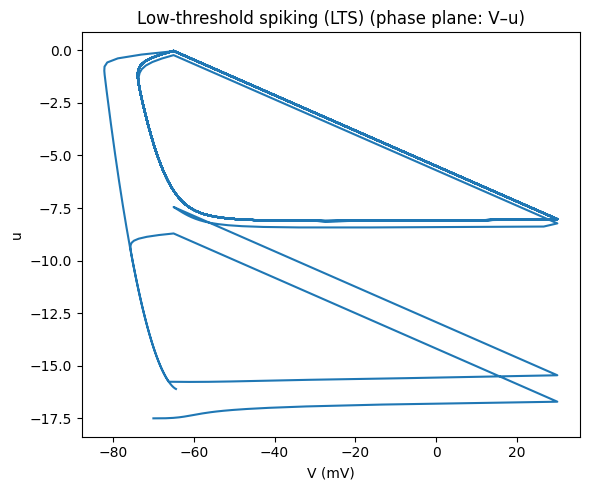

Low-threshold spiking (LTS): spikes=21, firing rate (100–750 ms) ≈ 29.2 Hz


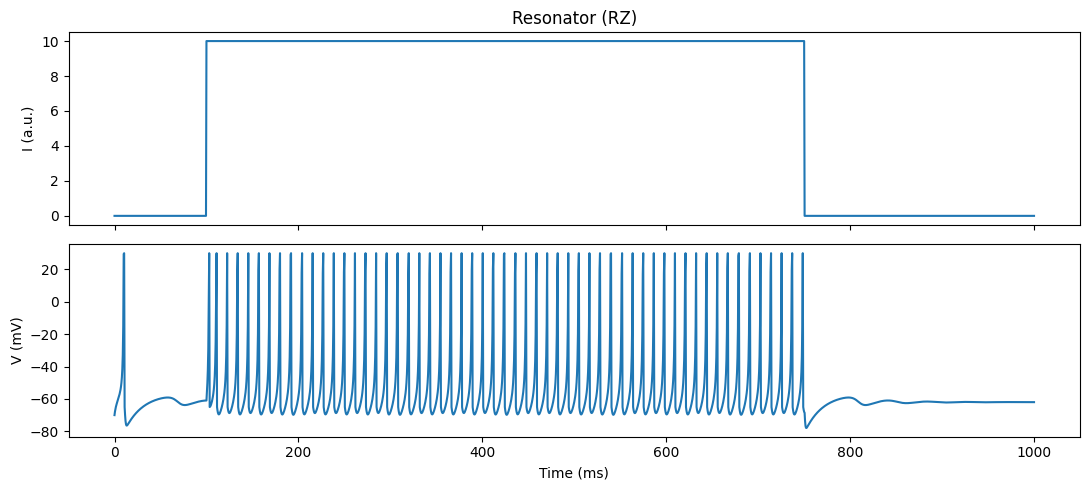

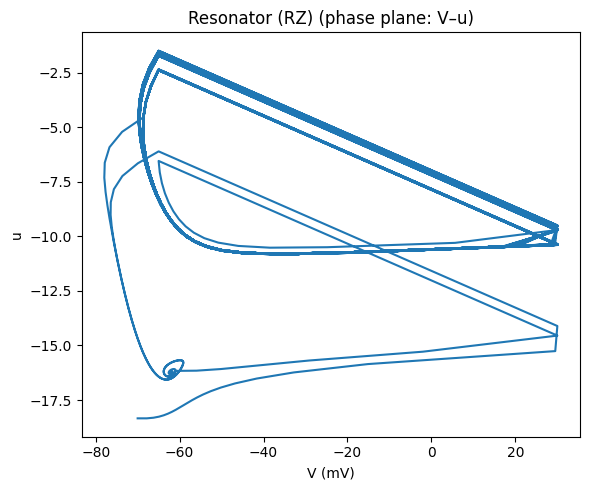

Resonator (RZ): spikes=58, firing rate (100–750 ms) ≈ 87.7 Hz


In [ ]:
dt = 0.5
time = make_time(t_max=1000.0, dt=dt)

I_ = stim_step(time, amp=10.0, t_on=100.0, t_off=750.0)

for name, p in PRESETS.items():
    V, u, spikes = izhikevich_sim(**p, dt=dt, time=time, I=I_, V_rest=-70.0)
    plot_v_and_I(name, time, V, I_)
    plot_phase_plane(name, V, u)
    print(f"{name}: spikes={len(spikes)}, firing rate (100–750 ms) ≈ {firing_rate(spikes, 100, 750):.1f} Hz")


## Demo 2: compact multi-type comparison in one figure

Same stimulus, but plots voltage traces for all presets on one axis.


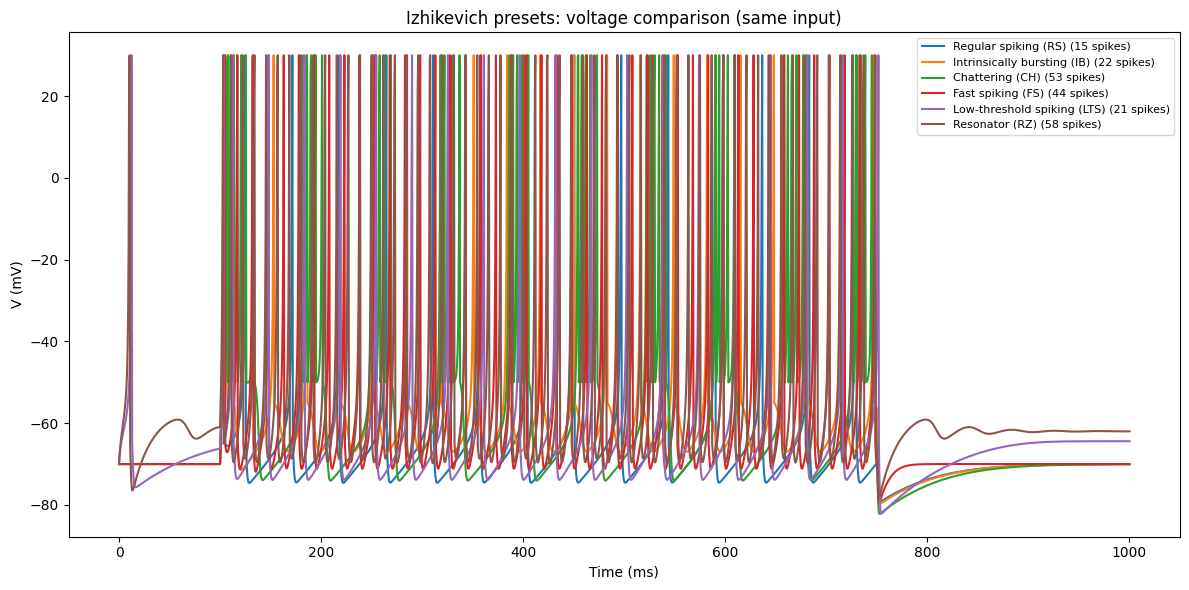

In [ ]:
def compare_types_voltage(time, I, presets=PRESETS, dt=0.5, V_rest=-70.0):
    plt.figure(figsize=(12, 6))
    for name, p in presets.items():
        V, u, spikes = izhikevich_sim(**p, dt=dt, time=time, I=I, V_rest=V_rest)
        plt.plot(time, V, label=f"{name} ({len(spikes)} spikes)")
    plt.xlabel('Time (ms)')
    plt.ylabel('V (mV)')
    plt.title('Izhikevich presets: voltage comparison (same input)')
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

compare_types_voltage(time, I_, presets=PRESETS, dt=dt)


## Extension 1: f–I curve (firing rate vs current amplitude)

For a chosen neuron type:
- sweep the step current amplitude
- compute firing rate in a stable window (200–750 ms)
- plot firing rate vs amplitude



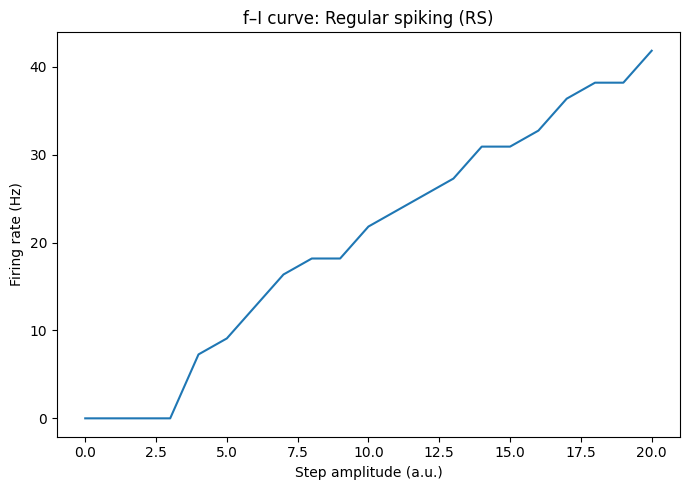

In [ ]:
def f_I_curve(preset_name, amps, dt=0.5, t_max=1000.0, t_on=100.0, t_off=750.0, rate_window=(200.0, 750.0)):
    p = PRESETS[preset_name]
    time = make_time(t_max=t_max, dt=dt)
    rates = []
    for A in amps:
        I = stim_step(time, amp=float(A), t_on=t_on, t_off=t_off)
        V, u, spikes = izhikevich_sim(**p, dt=dt, time=time, I=I)
        r = firing_rate(spikes, rate_window[0], rate_window[1])
        rates.append(r)
    return time, np.array(amps, dtype=float), np.array(rates, dtype=float)

amps = np.linspace(0, 20, 21)  # 0..20
preset = 'Regular spiking (RS)'
_, amps_, rates_ = f_I_curve(preset, amps)

plt.figure(figsize=(7, 5))
plt.plot(amps_, rates_)
plt.xlabel('Step amplitude (a.u.)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'f–I curve: {preset}')
plt.tight_layout()
plt.show()


## Extension 2: different stimulus protocols (pulse train / ramp / sine)

This shows how each neuron type responds to different inputs — useful for “characterization”.


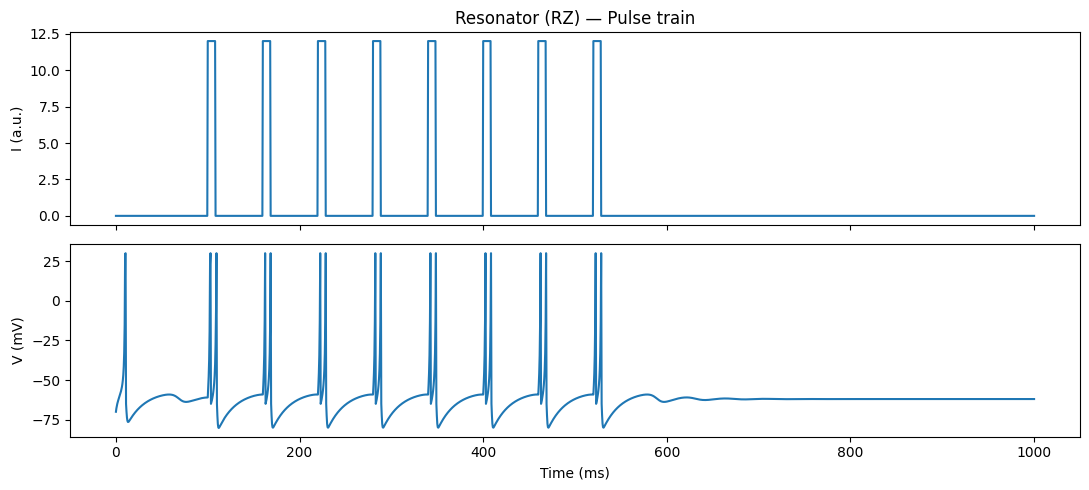

Pulse train: spikes=17


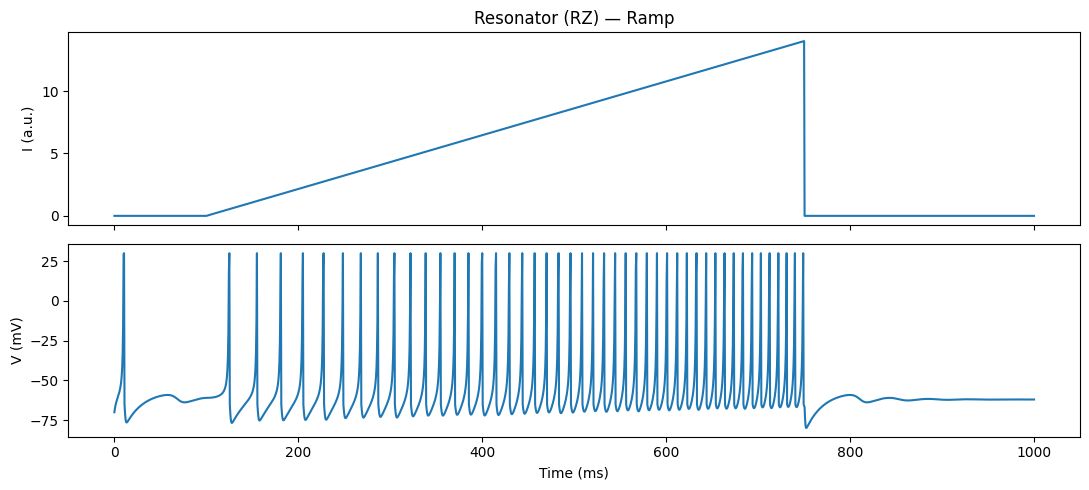

Ramp: spikes=47


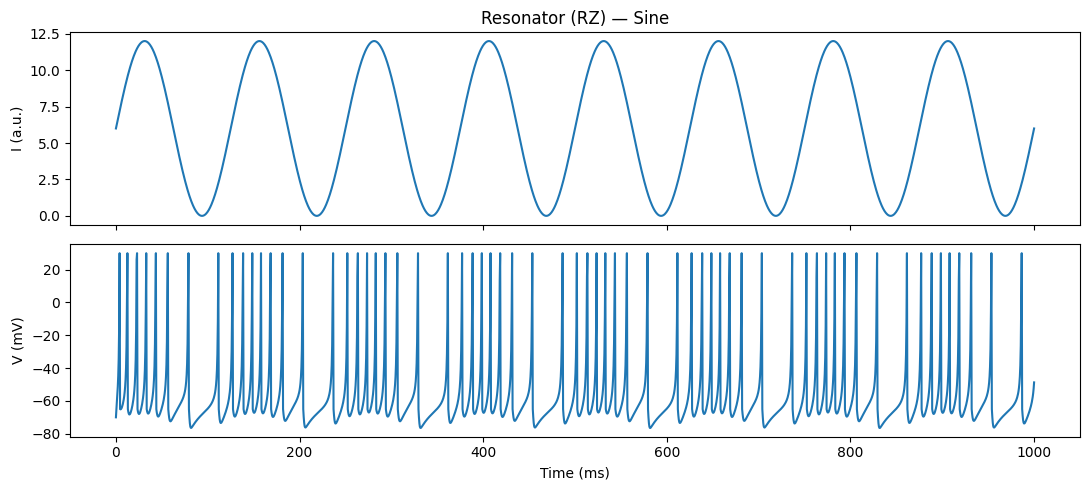

Sine: spikes=64


In [ ]:
time = make_time(t_max=1000.0, dt=0.5)

I_pulses = stim_pulse_train(time, amp=12.0, t_start=100.0, n_pulses=8, width=8.0, period=60.0)
I_ramp   = stim_ramp(time, amp_end=14.0, t_on=100.0, t_off=750.0)
I_sine   = stim_sine(time, amp=6.0, freq_hz=8.0, baseline=6.0)

test_preset = 'Resonator (RZ)'

for label, I in [('Pulse train', I_pulses), ('Ramp', I_ramp), ('Sine', I_sine)]:
    V, u, spikes = izhikevich_sim(**PRESETS[test_preset], dt=0.5, time=time, I=I)
    plot_v_and_I(f"{test_preset} — {label}", time, V, I)
    print(f"{label}: spikes={len(spikes)}")


## Extension 3: spike statistics (ISI distribution)

For any run, we compute inter-spike intervals (ISI) and look at variability/adaptation.


Number of spikes: 21
Mean ISI: 32.33 ms


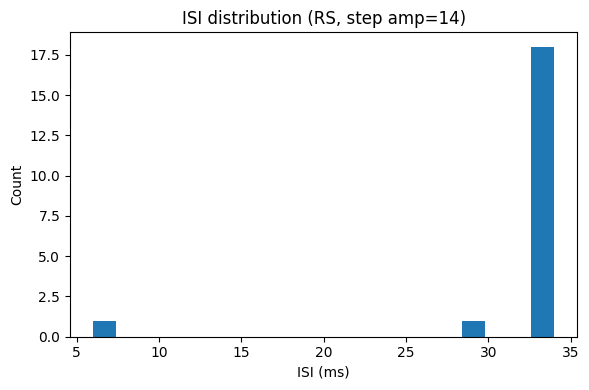

In [ ]:
def isi_ms(spike_times):
    if len(spike_times) < 2:
        return np.array([])
    return np.diff(np.array(spike_times, dtype=float))

# ISI histogram for RS with strong input
time = make_time(1000.0, 0.5)
I = stim_step(time, amp=14.0, t_on=100.0, t_off=750.0)
V, u, spikes = izhikevich_sim(**PRESETS['Regular spiking (RS)'], dt=0.5, time=time, I=I)

isis = isi_ms(spikes)
print(f"Number of spikes: {len(spikes)}")
print(f"Mean ISI: {isis.mean():.2f} ms" if len(isis) else "Not enough spikes for ISI")

plt.figure(figsize=(6, 4))
plt.hist(isis, bins=20)
plt.xlabel('ISI (ms)')
plt.ylabel('Count')
plt.title('ISI distribution (RS, step amp=14)')
plt.tight_layout()
plt.show()


# Extensions 4: analyses for firing patterns

- ISI adaptation plot (quantify RS/LTS adaptation)
- Burst detection + burst metrics (IB/CH)
- Nullclines in the (v,u) plane (phase-plane analysis)
- Parameter sweep (change one parameter and measure firing rate)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_isi_adaptation(spike_times, title="ISI adaptation"):
    """Plot ISI (ms) vs spike index to quantify adaptation."""
    if len(spike_times) < 2:
        print("Not enough spikes for ISI plot.")
        return
    isis = np.diff(np.array(spike_times, dtype=float))
    plt.figure(figsize=(6,4))
    plt.plot(np.arange(1, len(isis)+1), isis, 'o-')
    plt.xlabel("ISI index")
    plt.ylabel("ISI (ms)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def detect_bursts(spike_times, isi_threshold_ms=20.0, min_spikes_in_burst=2):
    """Group spikes into bursts based on an ISI threshold."""
    st = list(spike_times)
    if len(st) < 2:
        return []
    bursts = []
    current = [st[0]]
    for i in range(1, len(st)):
        isi = st[i] - st[i-1]
        if isi <= isi_threshold_ms:
            current.append(st[i])
        else:
            if len(current) >= min_spikes_in_burst:
                bursts.append(current)
            current = [st[i]]
    if len(current) >= min_spikes_in_burst:
        bursts.append(current)
    return bursts

def burst_report(spike_times, isi_threshold_ms=20.0):
    """Print basic burst stats."""
    bursts = detect_bursts(spike_times, isi_threshold_ms=isi_threshold_ms)
    print("Total spikes:", len(spike_times))
    print("Detected bursts:", len(bursts))
    if len(bursts):
        sizes = [len(b) for b in bursts]
        print("Burst sizes:", sizes)
        print("Mean burst size:", float(np.mean(sizes)))
    return bursts

def plot_izhikevich_nullclines(params, I_const, v_range=(-90, 40)):
    """Plot dv/dt=0 and du/dt=0 nullclines for the Izhikevich ODE part."""
    v = np.linspace(v_range[0], v_range[1], 500)
    u_vnull = 0.04*v**2 + 5*v + 140 + float(I_const)
    u_unull = float(params['b']) * v

    plt.figure(figsize=(6,5))
    plt.plot(v, u_vnull, label="dv/dt = 0")
    plt.plot(v, u_unull, label="du/dt = 0")
    plt.xlabel("v (mV)")
    plt.ylabel("u")
    plt.title(f"Izhikevich nullclines (I={I_const})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def sweep_one_param(base_params, param_name, values, time, I, dt=0.5, window=(100.0, 750.0)):
    """Sweep one parameter and plot firing rate vs that parameter."""
    rates = []
    for val in values:
        p = base_params.copy()
        p[param_name] = float(val)
        V, u, spikes = izhikevich_sim(**p, dt=dt, time=time, I=I)
        r = firing_rate(spikes, window[0], window[1])
        rates.append(r)

    plt.figure(figsize=(7,5))
    plt.plot(values, rates, 'o-')
    plt.xlabel(param_name)
    plt.ylabel("Firing rate (Hz)")
    plt.title(f"Sweep: firing rate vs {param_name}")
    plt.tight_layout()
    plt.show()


## Example usage

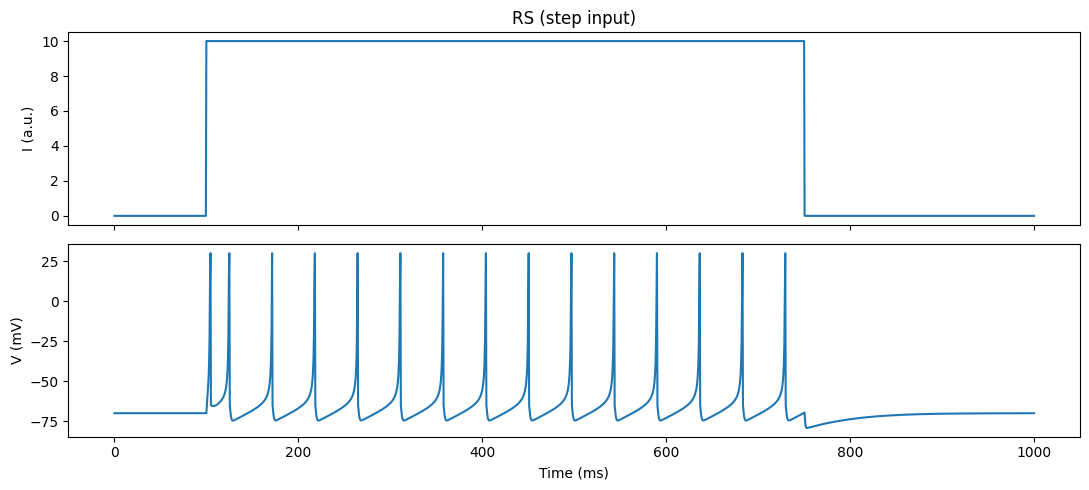

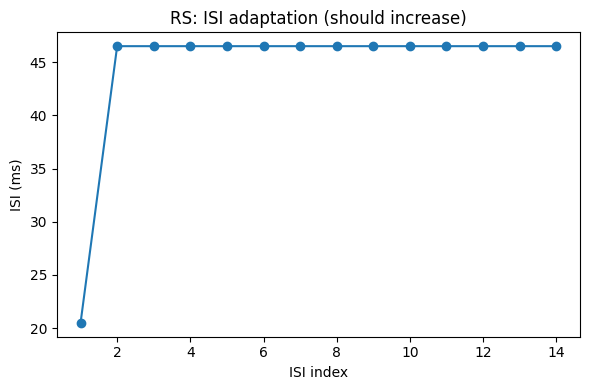

In [ ]:
# quantify RS adaptation using ISI plot
dt = 0.5
time = make_time(t_max=1000.0, dt=dt)
I_step_ = stim_step(time, amp=10.0, t_on=100.0, t_off=750.0)

V, u, spikes = izhikevich_sim(**PRESETS['Regular spiking (RS)'], dt=dt, time=time, I=I_step_)
plot_v_and_I("RS (step input)", time, V, I_step_)
plot_isi_adaptation(spikes, title="RS: ISI adaptation (should increase)")


In [ ]:
# burst report for IB and CH
for name in ['Intrinsically bursting (IB)', 'Chattering (CH)']:
    V, u, spikes = izhikevich_sim(**PRESETS[name], dt=0.5, time=time, I=I_step_)
    print("\n", name)
    _ = burst_report(spikes, isi_threshold_ms=25.0)



 Intrinsically bursting (IB)
Total spikes: 22
Detected bursts: 1
Burst sizes: [3]
Mean burst size: 3.0

 Chattering (CH)
Total spikes: 53
Detected bursts: 10
Burst sizes: [8, 5, 5, 5, 5, 5, 5, 5, 5, 5]
Mean burst size: 5.3


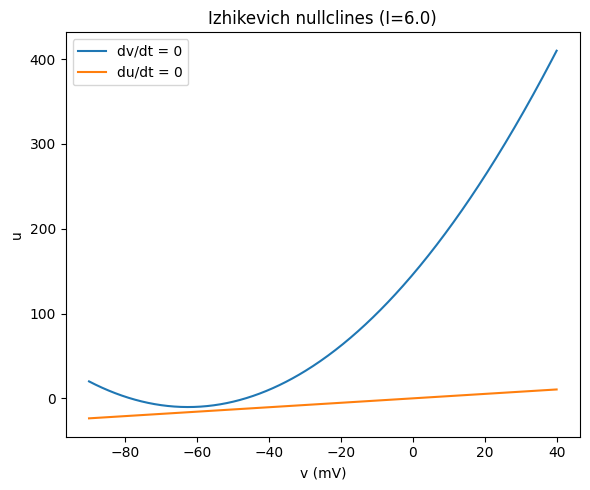

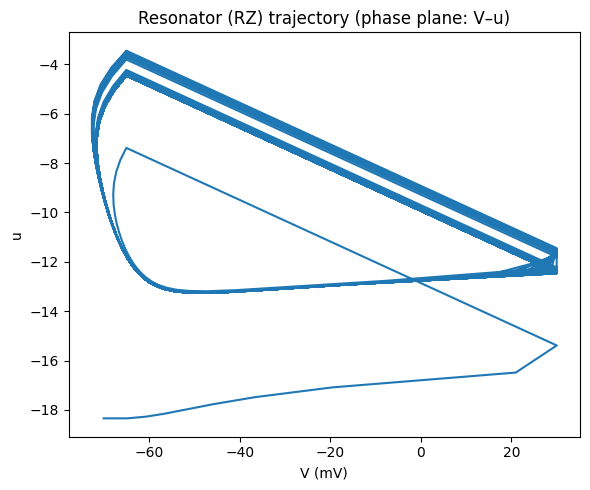

In [ ]:
# nullclines + trajectory in phase plane (v-u)
name = 'Resonator (RZ)'
params = PRESETS[name]
I_const = 6.0

I_const_vec = I_const * np.ones_like(time)
V, u, spikes = izhikevich_sim(**params, dt=0.5, time=time, I=I_const_vec)

plot_izhikevich_nullclines(params, I_const=I_const, v_range=(-90, 40))
plot_phase_plane(f"{name} trajectory", V, u)


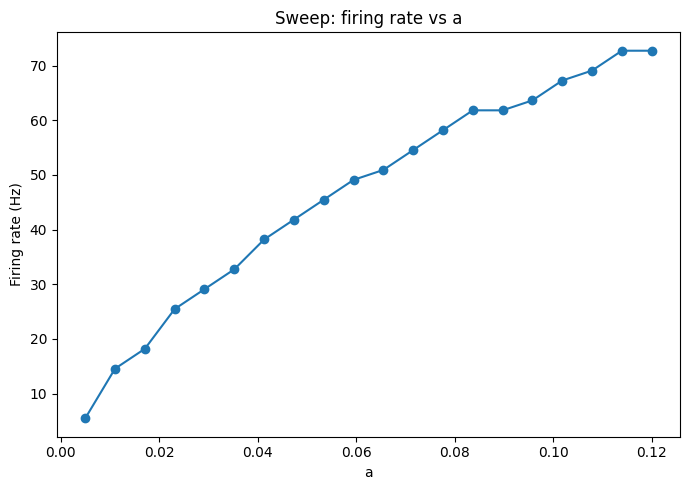

In [ ]:
# sweep a single parameter (a) and see firing-rate effect (RS)
base = PRESETS['Regular spiking (RS)'].copy()
vals = np.linspace(0.005, 0.12, 20)

sweep_one_param(base, 'a', vals, time, I_step_, dt=0.5, window=(200, 750))
